<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Aprendizaje Automático Avanzado</h1>
    <h3>Árboles de Decisión (Decision Trees)</h3>
    
</div>

> Los **árboles de decisión** es uno de los modelos más intuitivos e interpretables del Machine Learning. Además de ser útiles por sí mismos, son el **bloque de construcción** de los métodos de ensamble más potentes (Random Forest y Gradient Boosting), por lo que entenderlos bien es esencial dentro de los **algoritmos avanzados**.

## ¿Qué es un árbol de decisión?

Un **árbol de decisión** es un modelo que predice el valor de una variable objetivo **aprendiendo reglas de decisión sencillas** (`si ... entonces ...`) inferidas a partir de los datos.

>  **Analogía cotidiana:** decidir si llevar paraguas. *¿Está nublado?* → Sí → *¿La humedad es alta?* → Sí → **llevar paraguas**. Cada pregunta divide el problema hasta llegar a una decisión.

El modelo tiene forma de árbol invertido: empieza en un **nodo raíz** (arriba) y se ramifica mediante preguntas sobre las variables hasta llegar a las **hojas** (abajo), que contienen la predicción final.

Es un modelo **no paramétrico**: no asume una forma fija (como una recta) para la relación entre variables; la estructura crece según los datos.

Un ejemplo de árbol ya entrenado (inspirado en el dataset **Titanic** que usaremos más abajo):

```mermaid
flowchart TD
    A{¿sexo = mujer?} -->|Sí| B{¿clase <= 2?}
    A -->|No| C{¿edad < 6.5?}
    B -->|Sí| D[Sobrevive]
    B -->|No| E{¿tarifa < 20?}
    C -->|Sí| F[Sobrevive]
    C -->|No| G[No sobrevive]
    E -->|Sí| H[No sobrevive]
    E -->|No| I[Sobrevive]
```

## 2. Anatomía y terminología

```mermaid
flowchart TD
    R[Nodo raíz<br/>toda la muestra] --> N1[Nodo interno<br/>pregunta sobre una variable]
    R --> N2[Nodo interno]
    N1 --> L1[Hoja: clase A]
    N1 --> L2[Hoja: clase B]
    N2 --> L3[Hoja: clase A]
    N2 --> L4[Hoja: clase B]
```

| Término | Significado |
|---|---|
| **Nodo raíz** (*root*) | Nodo superior; contiene toda la muestra antes de dividir. |
| **Nodo interno** | Nodo con una condición de división sobre una variable. |
| **Rama** (*branch*) | Resultado de una condición (verdadero/falso). |
| **Hoja** (*leaf*) | Nodo terminal; entrega la predicción (clase o valor). |
| **Profundidad** (*depth*) | Número de niveles desde la raíz hasta la hoja más lejana. |
| **División** (*split*) | Partición de los datos según una condición. |

## ¿Cómo decide dónde dividir?

En cada nodo, el árbol prueba todas las variables y umbrales, y elige la división que produce nodos hijos lo más **"puros"** posible (que contengan mayoritariamente una sola clase). La *pureza* se mide con una **función de impureza**.

### Para clasificación

**Índice de Gini**: probabilidad de clasificar mal un elemento tomado al azar:
$$Gini = 1 - \sum_{i=1}^{C} p_i^2$$

**Entropía** (ganancia de información):
$$H = - \sum_{i=1}^{C} p_i \log_2 p_i$$

donde $p_i$ es la proporción de la clase $i$ en el nodo y $C$ el número de clases. Ambas valen **0** cuando el nodo es puro (una sola clase) y son **máximas** cuando las clases están equilibradas.

La **ganancia** de una división es la reducción de impureza:
$$\text{Ganancia} = I(\text{padre}) - \sum_{k} \frac{n_k}{n}\, I(\text{hijo}_k)$$

### Para regresión
Se minimiza el **error cuadrático medio** (MSE) o el **error absoluto medio** (MAE) dentro de cada nodo; la predicción de una hoja es el **promedio** de los valores que caen en ella.

Veamos numéricamente cómo cambia la impureza de un nodo según su composición de clases:

In [1]:
import numpy as np

def gini(p):
    p = np.array(p)
    return 1 - np.sum(p**2)

def entropia(p):
    p = np.array(p)
    p = p[p > 0]                     # evita log(0)
    return -np.sum(p * np.log2(p))

for prop in ([1.0, 0.0], [0.9, 0.1], [0.7, 0.3], [0.5, 0.5]):
    print(f'clases {prop} -> Gini={gini(prop):.3f} | Entropía={entropia(prop):.3f}')

clases [1.0, 0.0] -> Gini=0.000 | Entropía=-0.000
clases [0.9, 0.1] -> Gini=0.180 | Entropía=0.469
clases [0.7, 0.3] -> Gini=0.420 | Entropía=0.881
clases [0.5, 0.5] -> Gini=0.500 | Entropía=1.000


> Observemos que: un nodo **puro** `[1.0, 0.0]` tiene impureza 0; un nodo **totalmente mezclado** `[0.5, 0.5]` alcanza el máximo (Gini = 0.5, Entropía = 1.0). El árbol busca divisiones que **bajen** este valor.

## 4. El algoritmo CART

scikit-learn implementa **CART** (*Classification And Regression Trees*), que construye el árbol de forma **recursiva y voraz** (*greedy*):

1. En el nodo actual, evalúa **todas** las variables y umbrales posibles.
2. Elige la división que **maximiza la reducción de impureza**.
3. Divide los datos y repite el proceso en cada hijo.
4. **Se detiene** cuando: el nodo es puro, se alcanza `max_depth`, hay muy pocas muestras (`min_samples_split` / `min_samples_leaf`), o ninguna división mejora.

>  *Greedy* significa que toma la mejor decisión **local** en cada paso, sin garantizar el árbol globalmente óptimo (encontrar el óptimo es un problema NP-completo).

## Ejemplo real (clasificación):

Usaremos el dataset **Titanic** (real, con datos de pasajeros reales) para predecir la **supervivencia**. Contiene variables numéricas y categóricas, ideales para árboles.

In [2]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Dataset real de OpenML (se descarga y cachea la primera vez)
data = fetch_openml('titanic', version=1, as_frame=True)
df = data.frame


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB


In [6]:
X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()
X

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,female,29.0000,0,0,211.3375,S
1,1,male,0.9167,1,2,151.5500,S
2,1,female,2.0000,1,2,151.5500,S
3,1,male,30.0000,1,2,151.5500,S
4,1,female,25.0000,1,2,151.5500,S
...,...,...,...,...,...,...,...
1304,3,female,14.5000,1,0,14.4542,C
1305,3,female,NaN,1,0,14.4542,C
1306,3,male,26.5000,0,0,7.2250,C
1307,3,male,27.0000,0,0,7.2250,C


In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   sex       1309 non-null   category
 2   age       1046 non-null   float64 
 3   sibsp     1309 non-null   int64   
 4   parch     1309 non-null   int64   
 5   fare      1308 non-null   float64 
 6   embarked  1307 non-null   category
dtypes: category(2), float64(2), int64(3)
memory usage: 54.1 KB


In [12]:
X['age']=X['age'].fillna(np.mean(X['age']))

In [13]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   sex       1309 non-null   category
 2   age       1309 non-null   float64 
 3   sibsp     1309 non-null   int64   
 4   parch     1309 non-null   int64   
 5   fare      1308 non-null   float64 
 6   embarked  1307 non-null   category
dtypes: category(2), float64(2), int64(3)
memory usage: 54.1 KB


In [16]:
X[X['fare'].isna()]

,pclass,sex,age,sibsp,parch,fare,embarked
1225,3,male,60.5,0,0,NaN,S


In [18]:
X[X['pclass']==3]['fare'].mean()

13.302888700564973

In [19]:
X['fare']=X['fare'].fillna(X[X['pclass']==3]['fare'].mean())
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   sex       1309 non-null   category
 2   age       1309 non-null   float64 
 3   sibsp     1309 non-null   int64   
 4   parch     1309 non-null   int64   
 5   fare      1309 non-null   float64 
 6   embarked  1307 non-null   category
dtypes: category(2), float64(2), int64(3)
memory usage: 54.1 KB


In [21]:
X['embarked'].unique()

['S', 'C', NaN, 'Q']
Categories (3, object): ['C', 'Q', 'S']

In [20]:
X[X['embarked'].isna()]

,pclass,sex,age,sibsp,parch,fare,embarked
168,1,female,38.0,0,0,80.0,NaN
284,1,female,62.0,0,0,80.0,NaN


In [25]:
X[X['pclass']==1]['embarked'].value_counts()

embarked
S    177
C    141
Q      3
Name: count, dtype: int64

In [26]:
X['embarked'] = X['embarked'].fillna('S')

In [27]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   sex       1309 non-null   category
 2   age       1309 non-null   float64 
 3   sibsp     1309 non-null   int64   
 4   parch     1309 non-null   int64   
 5   fare      1309 non-null   float64 
 6   embarked  1309 non-null   category
dtypes: category(2), float64(2), int64(3)
memory usage: 54.1 KB


In [28]:
X['sex'].unique()

['female', 'male']
Categories (2, object): ['female', 'male']

In [30]:
# Preprocesamiento: codificar categóricas e imputar faltantes
X['sex'] = (X['sex']=='female').astype(int)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   sex       1309 non-null   int32   
 2   age       1309 non-null   float64 
 3   sibsp     1309 non-null   int64   
 4   parch     1309 non-null   int64   
 5   fare      1309 non-null   float64 
 6   embarked  1309 non-null   category
dtypes: category(1), float64(2), int32(1), int64(3)
memory usage: 57.8 KB


In [32]:
X['embarked'].unique()

['S', 'C', 'Q']
Categories (3, object): ['C', 'Q', 'S']

In [38]:
X = pd.get_dummies(X, columns=['embarked'], drop_first=True)

In [39]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      1309 non-null   int64  
 1   sex         1309 non-null   int32  
 2   age         1309 non-null   float64
 3   sibsp       1309 non-null   int64  
 4   parch       1309 non-null   int64  
 5   fare        1309 non-null   float64
 6   embarked_Q  1309 non-null   bool   
 7   embarked_S  1309 non-null   bool   
dtypes: bool(2), float64(2), int32(1), int64(3)
memory usage: 58.9 KB


In [44]:
y = df['survived'].astype(int)
y

0       1
1       1
2       0
3       0
4       0
       ..
1304    0
1305    0
1306    0
1307    0
1308    0
Name: survived, Length: 1309, dtype: int32

In [45]:
#Traintest split
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

clf = DecisionTreeClassifier(max_depth = 4, random_state = 42)
clf.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
help(DecisionTreeClassifier)

Help on class DecisionTreeClassifier in module sklearn.tree._classes:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)
 |  
 |  A decision tree classifier.
 |  
 |  Read more in the :ref:`User Guide <tree>`.
 |  
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy", "log_loss"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "log_loss" and "entropy" both for the
 |      Shannon information gain, see :ref:`tree_mathematical_formulation`.
 |  
 |  splitter : {"best", "random"}, default="best"
 |      The strategy used to choose the split at each node. Supported
 |      strat

In [46]:
pred = clf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test,pred)}')

Accuracy: 0.6793893129770993


In [49]:
print(classification_report(y_test, pred, target_names =['No sobreviviente', 'Sobreviviente']))

                  precision    recall  f1-score   support

No sobreviviente       0.68      0.92      0.78       162
   Sobreviviente       0.69      0.29      0.41       100

        accuracy                           0.68       262
       macro avg       0.68      0.60      0.59       262
    weighted avg       0.68      0.68      0.64       262



### Visualizar el árbol aprendido
Una gran ventaja: podemos **ver** exactamente las reglas que aprendió.

[]

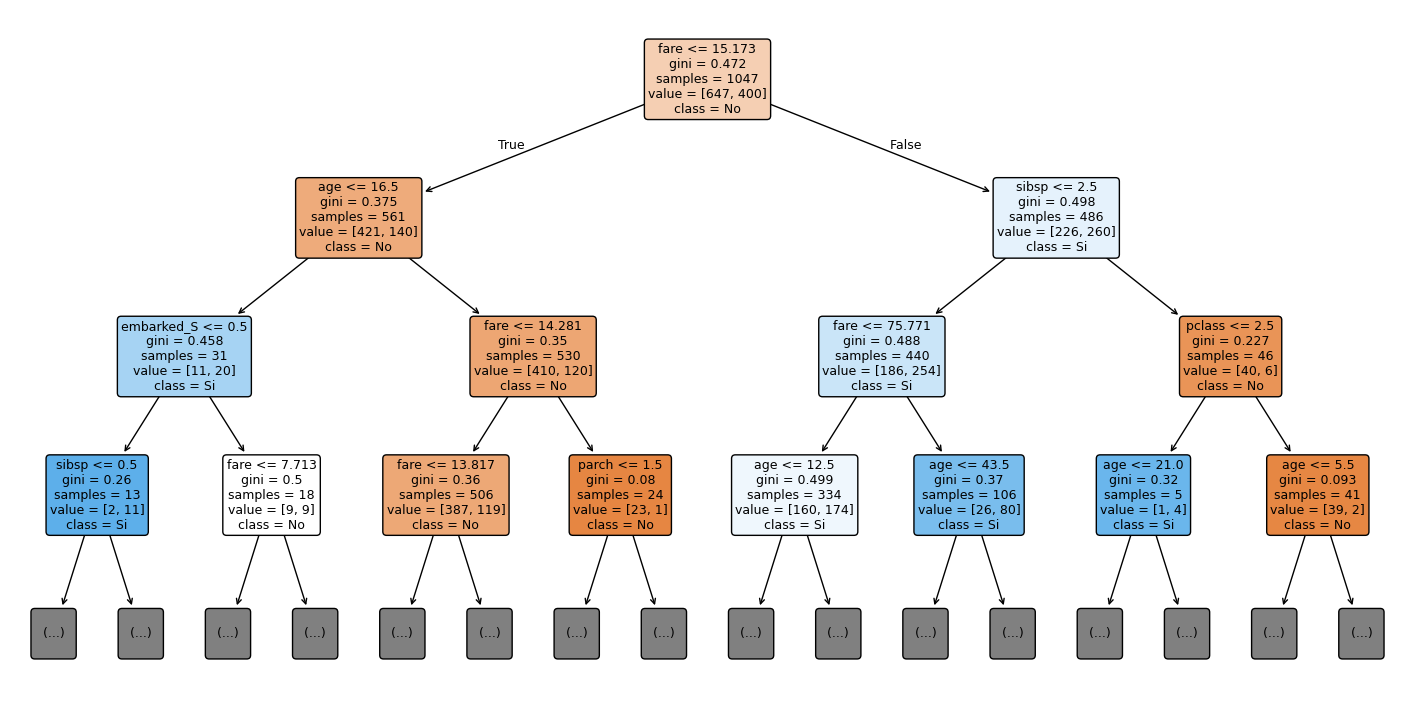

In [50]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,9))
plot_tree(clf, feature_names=list(X.columns), class_names = ['No', 'Si'], filled=True, rounded=True, fontsize=9, max_depth=3)
plt.plot()


In [51]:
clf.feature_importances_

array([0.04670286, 0.        , 0.23324252, 0.16108067, 0.00851129,
       0.53366666, 0.        , 0.01679601])

In [52]:
# Importancia de variables (reducción total de impureza aportada por cada una)
importancia = pd.Series(clf.feature_importances_, index = X.columns).sort_values()
importancia

sex           0.000000
embarked_Q    0.000000
parch         0.008511
embarked_S    0.016796
pclass        0.046703
sibsp         0.161081
age           0.233243
fare          0.533667
dtype: float64

<Axes: >

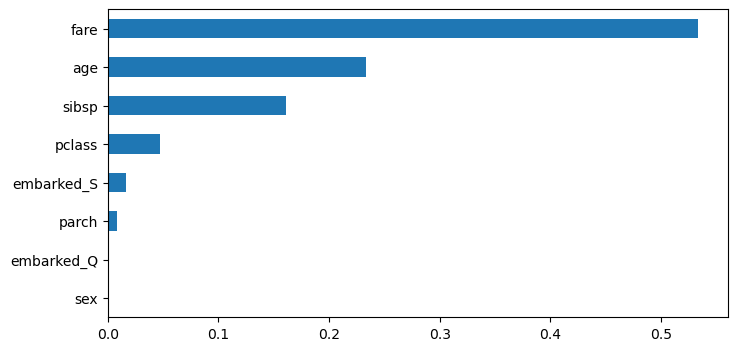

In [53]:
plt.figure(figsize=(8,4))
importancia.plot.barh()

## Ejemplo real (regresión): precios de vivienda en California

Los árboles también predicen **valores continuos**. Usaremos **California Housing** (20 640 viviendas reales) para predecir el precio mediano.

In [54]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [57]:
# ¿Qué variables usa más el árbol de regresión?
cal = fetch_california_housing(as_frame =True)
Xr, yr = cal.data, cal.target


In [60]:
X_train, X_test, y_train, y_test = train_test_split(Xr, yr, test_size = 0.2, random_state = 42)

In [64]:
reg = DecisionTreeRegressor(max_depth=6, random_state = 42).fit(X_train, y_train)


In [65]:
pred = reg.predict(X_test)

In [68]:
pred

array([1.11480881, 1.14983053, 3.78527446, ..., 4.87656933, 1.14983053,
       1.81744166])

In [66]:
mean_squared_error(pred, y_test)

0.4972838079675652

In [67]:
r2_score(pred, y_test)

0.43556240049027195

## Sobreajuste e hiperparámetros

Un árbol sin restricciones puede crecer hasta **memorizar** los datos de entrenamiento (hojas con 1 muestra) → **sobreajuste**. Los hiperparámetros controlan su complejidad:

| Hiperparámetro | Efecto | Para regularizar |
|---|---|---|
| `max_depth` | Profundidad máxima | **Reducir** |
| `min_samples_split` | Mínimo de muestras para dividir | Aumentar |
| `min_samples_leaf` | Mínimo de muestras por hoja | Aumentar |
| `max_features` | Variables consideradas por división | Reducir |
| `ccp_alpha` | Poda por complejidad (*cost-complexity pruning*) | Aumentar |

Veamos el efecto de `max_depth` sobre el rendimiento en entrenamiento vs. validación:

In [69]:
X

,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,1,0,29.000000,0,0,211.3375,False,True
1,1,0,0.916700,1,2,151.5500,False,True
2,1,0,2.000000,1,2,151.5500,False,True
3,1,0,30.000000,1,2,151.5500,False,True
4,1,0,25.000000,1,2,151.5500,False,True
...,...,...,...,...,...,...,...,...
1304,3,0,14.500000,1,0,14.4542,False,False
1305,3,0,29.881135,1,0,14.4542,False,False
1306,3,0,26.500000,0,0,7.2250,False,False
1307,3,0,27.000000,0,0,7.2250,False,False


In [70]:
y

0       1
1       1
2       0
3       0
4       0
       ..
1304    0
1305    0
1306    0
1307    0
1308    0
Name: survived, Length: 1309, dtype: int32

In [71]:
from sklearn.model_selection import validation_curve

dephts = range(1,21)

train_sc, val_sc = validation_curve(DecisionTreeClassifier(max_depth = 4, random_state = 42), X, y, param_name = 'max_depth', param_range = dephts, cv=5,
                                   scoring='accuracy')


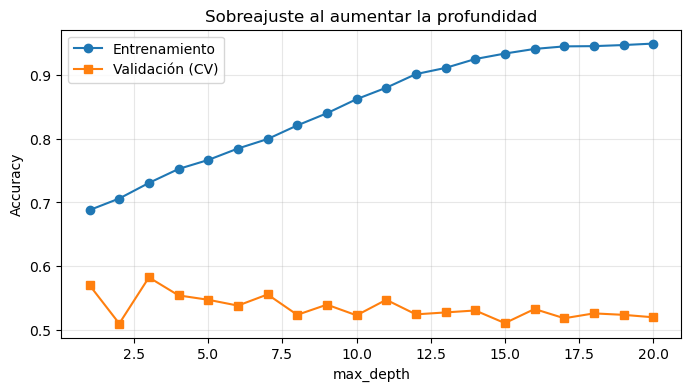

In [73]:
plt.figure(figsize=(8, 4))
plt.plot(dephts, train_sc.mean(axis=1), 'o-', label='Entrenamiento')
plt.plot(dephts, val_sc.mean(axis=1), 's-', label='Validación (CV)')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Sobreajuste al aumentar la profundidad')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

> Al aumentar la profundidad, el *accuracy* de entrenamiento sube casi a 1.0, pero el de validación se estanca o **cae**: eso es **sobreajuste**. El mejor `max_depth` es donde la curva de validación alcanza su máximo.

### Ventajas y desventajas

|  Ventajas |  Desventajas |
|---|---|
| Muy **interpretables** (reglas visibles) | **Inestables**: pequeños cambios en datos → árbol distinto |
| No requieren escalar las variables | Tienden al **sobreajuste** si no se podan |
| Manejan variables numéricas y categóricas | Fronteras de decisión "escalonadas" (ejes) |
| Capturan relaciones **no lineales** e interacciones | Un solo árbol suele ser **poco preciso** |
| Rápidos de entrenar y predecir | Sesgo hacia variables con muchos niveles |

>  La **inestabilidad** y el **sobreajuste** de un árbol individual son precisamente los problemas que resuelven los **ensambles** (Random Forest, Boosting).

## Interpretabilidad: extracción de las reglas aprendidas

Podemos exportar el árbol como **reglas de texto** legibles.

In [74]:
from sklearn.tree import export_text
# Árbol pequeño para que las reglas sean legibles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)
arbol_simple = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
print(export_text(arbol_simple, feature_names = list(X.columns)))



|--- fare <= 15.17
|   |--- age <= 16.50
|   |   |--- embarked_S <= 0.50
|   |   |   |--- class: 1
|   |   |--- embarked_S >  0.50
|   |   |   |--- class: 0
|   |--- age >  16.50
|   |   |--- fare <= 14.28
|   |   |   |--- class: 0
|   |   |--- fare >  14.28
|   |   |   |--- class: 0
|--- fare >  15.17
|   |--- sibsp <= 2.50
|   |   |--- fare <= 75.77
|   |   |   |--- class: 1
|   |   |--- fare >  75.77
|   |   |   |--- class: 1
|   |--- sibsp >  2.50
|   |   |--- pclass <= 2.50
|   |   |   |--- class: 1
|   |   |--- pclass >  2.50
|   |   |   |--- class: 0



## Conexión con los métodos de ensamble

Un árbol individual es **débil e inestable**, pero es un **excelente bloque de construcción**. Combinando muchos árboles obtenemos los algoritmos más potentes para datos estructurados:

```mermaid
flowchart LR
    T[Árbol de decisión] --> RF[Random Forest<br/>bagging de árboles]
    T --> GB[Gradient Boosting<br/>boosting de árboles]
    RF --> X1[XGBoost / LightGBM / CatBoost]
    GB --> X1
```


- Un **árbol de decisión** aprende reglas `si/entonces` dividiendo los datos para maximizar la **pureza** de los nodos (Gini/entropía en clasificación, MSE en regresión).
- Usa el algoritmo **CART**, recursivo y voraz, con criterios de parada.
- Es **interpretable** y flexible, pero **inestable** y propenso al **sobreajuste** (se controla con `max_depth`, `min_samples_leaf`, poda, etc.).
- Es la **base** de Random Forest y Gradient Boosting.

[scikit-learn — Decision Trees](https://scikit-learn.org/stable/modules/tree.html)
